In [ ]:
!mkdir -p data

!wget -P data https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
!wget -P data https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!wget -P data https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

--2026-07-13 02:29:14--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘data/GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  19.4MB/s    in 15s     

2026-07-13 02:29:29 (17.6 MB/s) - ‘data/GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]

--2026-07-13 02:29:29--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘data/GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[============

In [ ]:
!mkdir -p data

!unzip -q -n data/GTSRB_Final_Training_Images.zip -d data
!unzip -q -n data/GTSRB_Final_Test_Images.zip -d data
!unzip -q -n data/GTSRB_Final_Test_GT.zip -d data

In [ ]:
!find data -maxdepth 4 -type d | head -20

data
data/GTSRB
data/GTSRB/Final_Training
data/GTSRB/Final_Training/Images
data/GTSRB/Final_Training/Images/00030
data/GTSRB/Final_Training/Images/00005
data/GTSRB/Final_Training/Images/00008
data/GTSRB/Final_Training/Images/00021
data/GTSRB/Final_Training/Images/00025
data/GTSRB/Final_Training/Images/00032
data/GTSRB/Final_Training/Images/00023
data/GTSRB/Final_Training/Images/00033
data/GTSRB/Final_Training/Images/00018
data/GTSRB/Final_Training/Images/00034
data/GTSRB/Final_Training/Images/00019
data/GTSRB/Final_Training/Images/00006
data/GTSRB/Final_Training/Images/00007
data/GTSRB/Final_Training/Images/00037
data/GTSRB/Final_Training/Images/00010
data/GTSRB/Final_Training/Images/00002


In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
TRAIN_DIR = "/content/data/GTSRB/Final_Training/Images"
TEST_DIR = "/content/data/GTSRB/Final_Test/Images"

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


In [ ]:
csv_files = sorted(glob.glob(os.path.join(TRAIN_DIR, "*", "GT-*.csv")))

print("Số file CSV label:", len(csv_files))
print(csv_files[:5])

Số file CSV label: 43
['/content/data/GTSRB/Final_Training/Images/00000/GT-00000.csv', '/content/data/GTSRB/Final_Training/Images/00001/GT-00001.csv', '/content/data/GTSRB/Final_Training/Images/00002/GT-00002.csv', '/content/data/GTSRB/Final_Training/Images/00003/GT-00003.csv', '/content/data/GTSRB/Final_Training/Images/00004/GT-00004.csv']


In [ ]:
sample_csv = csv_files[0]
df_sample = pd.read_csv(sample_csv, sep=";")

print(sample_csv)
df_sample.head()

/content/data/GTSRB/Final_Training/Images/00000/GT-00000.csv


,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000_00000.ppm,29,30,5,6,24,25,0
1,00000_00001.ppm,30,30,5,5,25,25,0
2,00000_00002.ppm,30,30,5,5,25,25,0
3,00000_00003.ppm,31,31,5,5,26,26,0
4,00000_00004.ppm,30,32,5,6,25,26,0


In [ ]:
IMG_SIZE = (32, 32)

def extract_hog_feature(image_path, roi=None):
    # Đọc ảnh bằng OpenCV
    img = cv2.imread(image_path)

    if img is None:
        return None

    # OpenCV đọc ảnh dạng BGR, đổi sang RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Nếu có ROI thì crop đúng vùng biển báo
    if roi is not None:
        x1, y1, x2, y2 = roi
        img = img[y1:y2+1, x1:x2+1]

    # Resize ảnh về cùng kích thước
    img = cv2.resize(img, IMG_SIZE)

    # HOG thường dùng ảnh grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Extract HOG feature
    feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    return feature.astype("float32")

In [ ]:
sample_csv = csv_files[0]
df_sample = pd.read_csv(sample_csv, sep=";")

sample_row = df_sample.iloc[0]
sample_folder = os.path.dirname(sample_csv)
sample_image_path = os.path.join(sample_folder, sample_row["Filename"])

roi = (
    int(sample_row["Roi.X1"]),
    int(sample_row["Roi.Y1"]),
    int(sample_row["Roi.X2"]),
    int(sample_row["Roi.Y2"])
)

feature = extract_hog_feature(sample_image_path, roi)

print("Image path:", sample_image_path)
print("ClassId:", sample_row["ClassId"])
print("HOG feature shape:", feature.shape)
print("First 10 values:", feature[:10])

Image path: /content/data/GTSRB/Final_Training/Images/00000/00000_00000.ppm
ClassId: 0
HOG feature shape: (324,)
First 10 values: [0.03778902 0.03286696 0.02817982 0.09768153 0.32963112 0.12780431
 0.01549799 0.02103676 0.01497179 0.01719324]


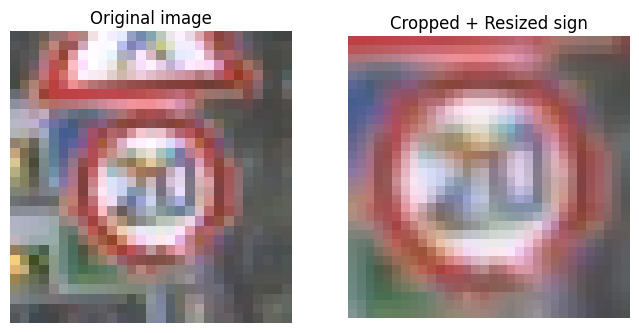

In [ ]:
import matplotlib.pyplot as plt

img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x1, y1, x2, y2 = roi
crop = img[y1:y2+1, x1:x2+1]
crop_resized = cv2.resize(crop, IMG_SIZE)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(crop_resized)
plt.title("Cropped + Resized sign")
plt.axis("off")

plt.show()

In [ ]:
X = []
y = []

for csv_path in tqdm(csv_files):
    class_folder = os.path.dirname(csv_path)
    df = pd.read_csv(csv_path, sep=";")

    for _, row in df.iterrows():
        image_path = os.path.join(class_folder, row["Filename"])

        roi = (
            int(row["Roi.X1"]),
            int(row["Roi.Y1"]),
            int(row["Roi.X2"]),
            int(row["Roi.Y2"])
        )

        feature = extract_hog_feature(image_path, roi)

        if feature is not None:
            X.append(feature)
            y.append(int(row["ClassId"]))

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))

100%|██████████| 43/43 [00:30<00:00,  1.42it/s]


X shape: (39209, 324)
y shape: (39209,)
Number of classes: 43


In [ ]:
np.savez(
    "/content/gtsrb_hog_32x32_train_features.npz",
    X=X,
    y=y
)

print("Saved HOG features successfully!")

Saved HOG features successfully!


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

NameError: name 'X' is not defined

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

model = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=10000,
        dual=False,
        random_state=42
    )
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(class_weight='balanced', dual=False, max_iter=10000,
                           random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_acc)
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.9236164243815354
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.84      0.75      0.79       444
           2       0.80      0.81      0.80       450
           3       0.91      0.91      0.91       282
           4       0.96      0.96      0.96       396
           5       0.75      0.69      0.72       372
           6       0.99      1.00      0.99        84
           7       0.87      0.93      0.90       288
           8       0.84      0.84      0.84       282
           9       0.96      0.97      0.96       294
          10       0.97      0.98      0.97       402
          11       0.91      0.83      0.87       264
          12       0.99      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       0.99      1.00      1.00       156
          15       0.99      0.98      0.98       126
          16       0.95      1.00      0.

In [ ]:
import joblib

joblib.dump(model, "/content/hog_svm_gtsrb_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os
import glob
import cv2
import pandas as pd
import matplotlib.pyplot as plt

TEST_DIR = "/content/data/GTSRB/Final_Test/Images"

# Tìm file ground truth của test set
test_gt_candidates = glob.glob("/content/data/**/GT-final_test.csv", recursive=True)
print(test_gt_candidates)

TEST_GT_PATH = test_gt_candidates[0]
test_df = pd.read_csv(TEST_GT_PATH, sep=";")

test_df.head()

['/content/data/GT-final_test.csv']


,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000.ppm,53,54,6,5,48,49,16
1,00001.ppm,42,45,5,5,36,40,1
2,00002.ppm,48,52,6,6,43,47,38
3,00003.ppm,27,29,5,5,22,24,33
4,00004.ppm,60,57,5,5,55,52,11


In [ ]:
class_names = {
    0: "Speed limit 20 km/h",
    1: "Speed limit 30 km/h",
    2: "Speed limit 50 km/h",
    3: "Speed limit 60 km/h",
    4: "Speed limit 70 km/h",
    5: "Speed limit 80 km/h",
    6: "End of speed limit 80 km/h",
    7: "Speed limit 100 km/h",
    8: "Speed limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve to the left",
    20: "Dangerous curve to the right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

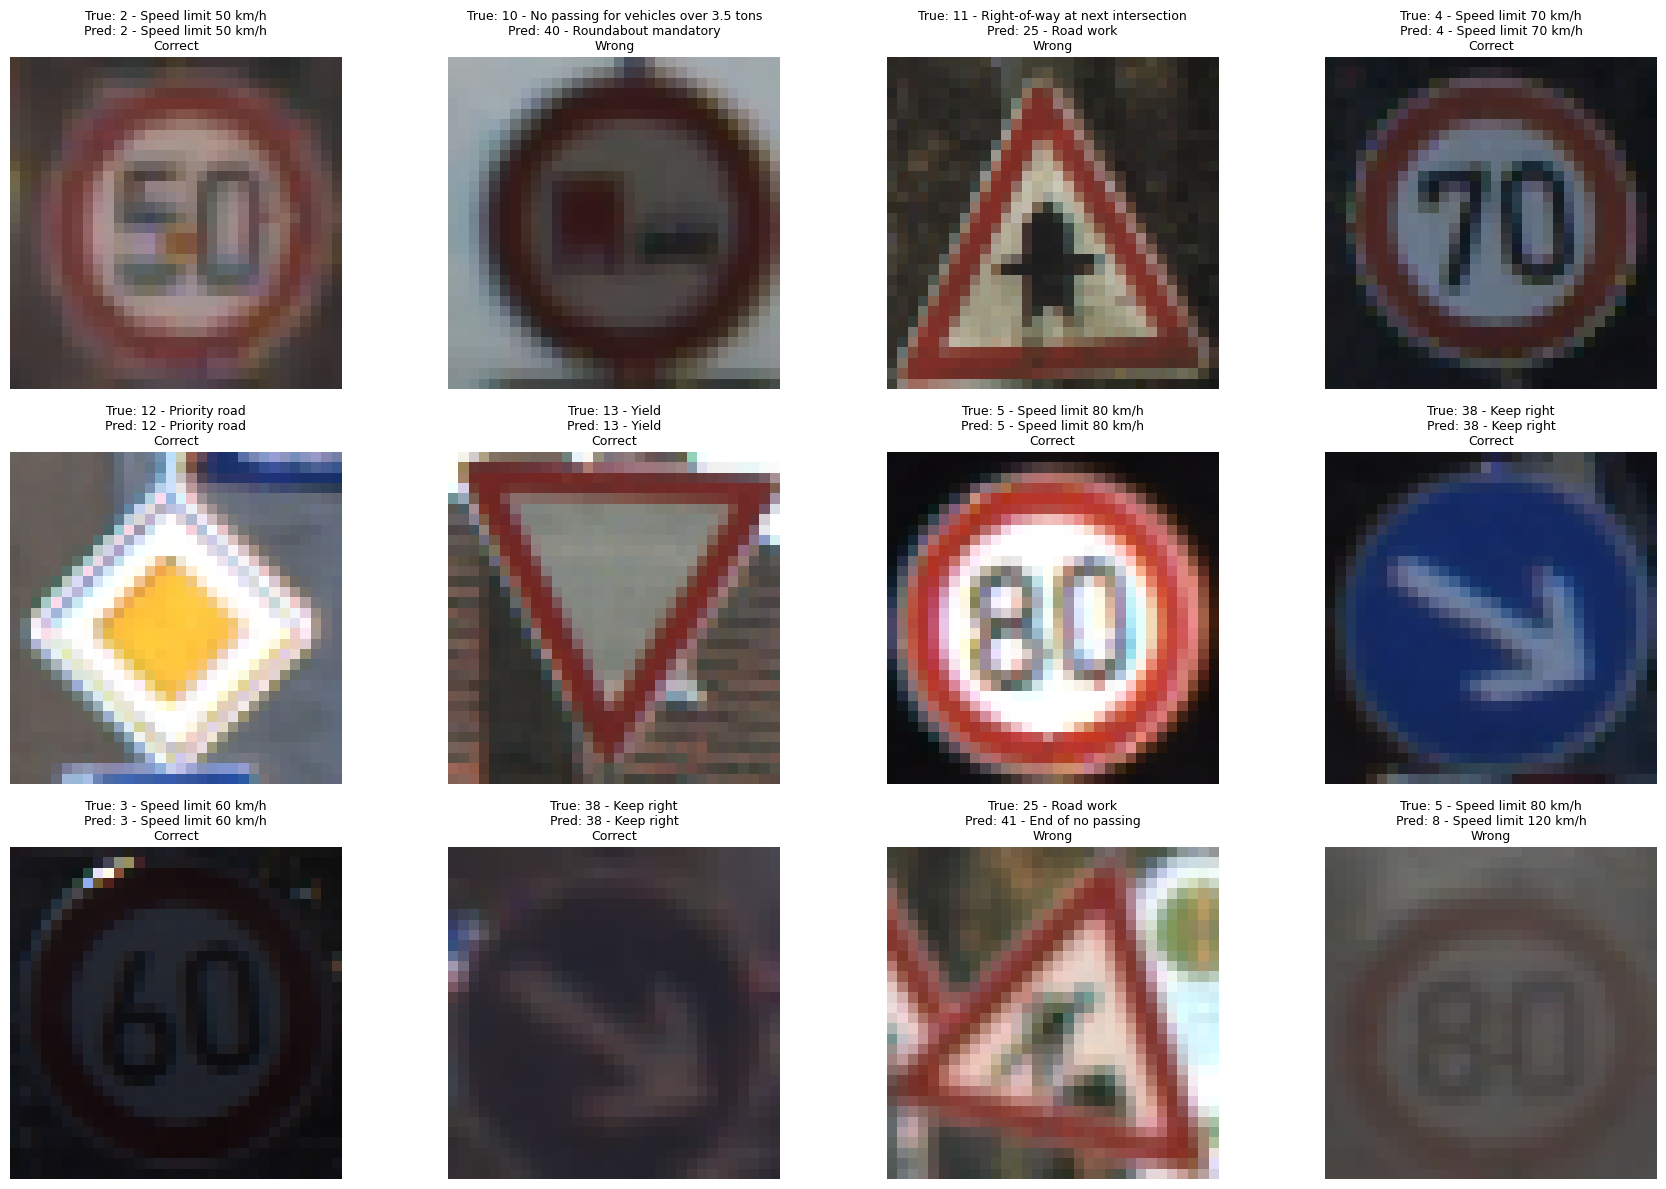

In [ ]:
# Chọn ngẫu nhiên 12 ảnh test
sample_df = test_df.sample(n=12, random_state=42)

plt.figure(figsize=(18, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    image_path = os.path.join(TEST_DIR, row["Filename"])

    roi = (
        int(row["Roi.X1"]),
        int(row["Roi.Y1"]),
        int(row["Roi.X2"]),
        int(row["Roi.Y2"])
    )

    # Extract HOG feature
    feature = extract_hog_feature(image_path, roi)

    # Predict bằng model đã train
    pred = model.predict([feature])[0]
    true_label = int(row["ClassId"])

    # Đọc ảnh để hiển thị
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x1, y1, x2, y2 = roi
    crop = img[y1:y2+1, x1:x2+1]
    crop = cv2.resize(crop, IMG_SIZE)

    true_name = class_names[true_label]
    pred_name = class_names[pred]

    result = "Correct" if pred == true_label else "Wrong"

    plt.subplot(3, 4, i + 1)
    plt.imshow(crop)
    plt.axis("off")
    plt.title(
        f"True: {true_label} - {true_name}\n"
        f"Pred: {pred} - {pred_name}\n"
        f"{result}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

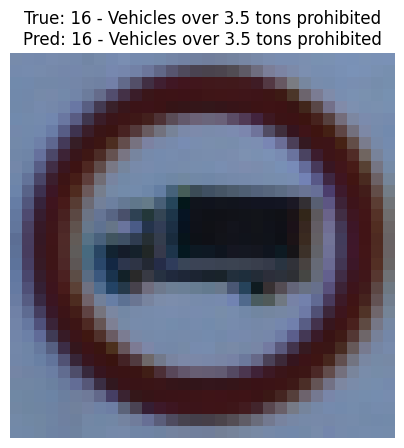

Image path: /content/data/GTSRB/Final_Test/Images/00000.ppm
True label: 16
True name: Vehicles over 3.5 tons prohibited
Predicted label: 16
Predicted name: Vehicles over 3.5 tons prohibited
Result: Correct


In [ ]:
idx = 0  # đổi số này để test ảnh khác

row = test_df.iloc[idx]
image_path = os.path.join(TEST_DIR, row["Filename"])

roi = (
    int(row["Roi.X1"]),
    int(row["Roi.Y1"]),
    int(row["Roi.X2"]),
    int(row["Roi.Y2"])
)

feature = extract_hog_feature(image_path, roi)

pred = model.predict([feature])[0]
true_label = int(row["ClassId"])

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x1, y1, x2, y2 = roi
crop = img[y1:y2+1, x1:x2+1]
crop = cv2.resize(crop, IMG_SIZE)

true_name = class_names[true_label]
pred_name = class_names[pred]

plt.figure(figsize=(5, 5))
plt.imshow(crop)
plt.axis("off")
plt.title(
    f"True: {true_label} - {true_name}\n"
    f"Pred: {pred} - {pred_name}"
)
plt.show()

print("Image path:", image_path)
print("True label:", true_label)
print("True name:", true_name)
print("Predicted label:", pred)
print("Predicted name:", pred_name)

if pred == true_label:
    print("Result: Correct")
else:
    print("Result: Wrong")

In [ ]:
sample_df = test_df.sample(n=20, random_state=7)

results = []

for _, row in sample_df.iterrows():
    image_path = os.path.join(TEST_DIR, row["Filename"])

    roi = (
        int(row["Roi.X1"]),
        int(row["Roi.Y1"]),
        int(row["Roi.X2"]),
        int(row["Roi.Y2"])
    )

    feature = extract_hog_feature(image_path, roi)

    pred = model.predict([feature])[0]
    true_label = int(row["ClassId"])

    results.append({
        "Filename": row["Filename"],
        "True Label": true_label,
        "True Name": class_names[true_label],
        "Predicted Label": pred,
        "Predicted Name": class_names[pred],
        "Correct": pred == true_label
    })

results_df = pd.DataFrame(results)
results_df

,Filename,True Label,True Name,Predicted Label,Predicted Name,Correct
0,10973.ppm,14,Stop,14,Stop,True
1,08611.ppm,5,Speed limit 80 km/h,36,Go straight or right,False
2,02369.ppm,13,Yield,13,Yield,True
3,07633.ppm,11,Right-of-way at next intersection,11,Right-of-way at next intersection,True
4,09685.ppm,7,Speed limit 100 km/h,7,Speed limit 100 km/h,True
5,02288.ppm,30,Beware of ice/snow,11,Right-of-way at next intersection,False
6,10023.ppm,4,Speed limit 70 km/h,4,Speed limit 70 km/h,True
7,10626.ppm,9,No passing,9,No passing,True
8,00896.ppm,15,No vehicles,15,No vehicles,True
9,03772.ppm,1,Speed limit 30 km/h,1,Speed limit 30 km/h,True
